# Sprint 5

## Install PySpark

In [12]:
!pip3 install pandas
%pip install plotly


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("pyspark") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyspark"])
    print("Installed pyspark.")
else:
    print("pyspark is already available.")

pyspark is already available.


## Spark session

In [14]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("CS131_bladdards")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

print("Spark version:", spark.version)
print("Shuffle partitions:", spark.conf.get("spark.sql.shuffle.partitions"))

Spark version: 4.1.1
Shuffle partitions: 8


## Import the funtions and create data path

In [17]:
from pathlib import Path
from itertools import chain
import plotly.express as px
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.window import Window
import pyspark.sql.functions as F 
from pyspark.sql.functions import (
    col,
    to_date,
    year,
    avg,
    count,
    count_distinct,
    broadcast,
    substring,
    min as spark_min,
    max as spark_max,
    mean,
    approx_percentile,
    when
)

DATA_DIR = Path("../data/MIMIC-IV/hosp")
GENERAL_DATA_DIR = Path("../data/raw")
EVIDENCE_DIR = Path("../out/evidence")
VISIT_DF = Path("../data/processed/visits")
DIAGNOSES_DF = Path("../data/processed/diagnoses")
ICD_CODES_DF = Path("../data/processed/icd_codes")

In [20]:
from pathlib import Path
from itertools import chain
import plotly.express as px
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.window import Window
import pyspark.sql.functions as F 
from pyspark.sql.functions import (
    col,
    to_date,
    year,
    avg,
    count,
    count_distinct,
    broadcast,
    substring,
    min as spark_min,
    max as spark_max,
    mean,
    approx_percentile,
    when
)

VISIT_DF = Path("../data/processed/visits").resolve()
DIAGNOSES_DF = Path("../data/processed/diagnoses").resolve()
ICD_CODES_DF = Path("../data/processed/icd_codes").resolve()

print("VISIT_DF =", VISIT_DF)
print("exists?", VISIT_DF.exists())
print("contents:", list(VISIT_DF.glob("*"))[:5])

VISIT_DF = /Users/aradhana_anandkumar/Desktop/UNDERGRAD/2nd_YEAR/CS_131/Project_Work/data/processed/visits
exists? True
contents: [PosixPath('/Users/aradhana_anandkumar/Desktop/UNDERGRAD/2nd_YEAR/CS_131/Project_Work/data/processed/visits/._SUCCESS.crc'), PosixPath('/Users/aradhana_anandkumar/Desktop/UNDERGRAD/2nd_YEAR/CS_131/Project_Work/data/processed/visits/.part-00000-0106be0a-7060-4c0f-8bb7-5d203e0c945f-c000.snappy.parquet.crc'), PosixPath('/Users/aradhana_anandkumar/Desktop/UNDERGRAD/2nd_YEAR/CS_131/Project_Work/data/processed/visits/_SUCCESS'), PosixPath('/Users/aradhana_anandkumar/Desktop/UNDERGRAD/2nd_YEAR/CS_131/Project_Work/data/processed/visits/part-00000-0106be0a-7060-4c0f-8bb7-5d203e0c945f-c000.snappy.parquet')]


In [21]:
from pathlib import Path
p = Path("../data/processed/visits").resolve()

print("absolute:", p)
print("exists:", p.exists())
print("is_dir:", p.is_dir())
print("children:", [x.name for x in p.iterdir()][:10])

absolute: /Users/aradhana_anandkumar/Desktop/UNDERGRAD/2nd_YEAR/CS_131/Project_Work/data/processed/visits
exists: True
is_dir: True
children: ['._SUCCESS.crc', '.part-00000-0106be0a-7060-4c0f-8bb7-5d203e0c945f-c000.snappy.parquet.crc', '_SUCCESS', 'part-00000-0106be0a-7060-4c0f-8bb7-5d203e0c945f-c000.snappy.parquet']


## Dataframes

In [5]:
# -------------------------------------------------------
# Pulling Dataframes from Saved Parquet Files
# -------------------------------------------------------
visits = spark.read.parquet(str(VISIT_DF))
visits.show(10, truncate=False)

diagnoses = spark.read.parquet(str(DIAGNOSES_DF))
diagnoses.show(10, truncate=False)

icd_codes = spark.read.parquet(str(ICD_CODES_DF))
icd_codes.show(10, truncate=False)



+----------+--------+----------------------+------+-----------+---+----------+
|subject_id|hadm_id |race                  |gender|visit_type |age|admit_day |
+----------+--------+----------------------+------+-----------+---+----------+
|10001401  |21544441|WHITE                 |F     |BC_FIRST_DX|89 |2014-06-04|
|10004235  |25970245|BLACK/CAPE VERDEAN    |M     |BC_FIRST_DX|47 |2014-06-15|
|10015568  |26581506|BLACK/AFRICAN         |M     |BC_FIRST_DX|65 |2011-08-19|
|10024451  |22358047|WHITE                 |M     |BC_FIRST_DX|70 |2020-09-14|
|10024483  |27517184|BLACK/AFRICAN AMERICAN|M     |BC_FIRST_DX|82 |2008-07-03|
|10026950  |28254249|WHITE                 |M     |BC_FIRST_DX|91 |2011-03-14|
|10041408  |29176109|WHITE                 |F     |BC_FIRST_DX|58 |2008-08-29|
|10068474  |25255224|WHITE                 |F     |BC_FIRST_DX|71 |2017-02-07|
|10070928  |26961908|WHITE                 |M     |BC_FIRST_DX|87 |2008-04-05|
|10085948  |28355680|WHITE                 |F     |B

In [6]:
# Finding out the top Relevant symptoms from each
# Making sure to have one output that merges
#Create a dictionary for symptom groups
symptom_group ={"78900":"Abdominal pain","78901":"Abdominal pain","78902":"Abdominal pain","78903":"Abdominal pain","78904":"Abdominal pain","78905":"Abdominal pain","78906":"Abdominal pain","78907":"Abdominal pain","78909":"Abdominal pain","R1010":"Abdominal pain","R102":"Abdominal pain","R1030":"Abdominal pain","R1031":"Abdominal pain","R1032":"Abdominal pain","R108":"Abdominal pain","R1084":"Abdominal pain","R109":"Abdominal pain","R141":"Abdominal pain","57400":"Calculus","57401":"Calculus","57410":"Calculus","57411":"Calculus","57420":"Calculus","57421":"Calculus","57430":"Calculus","57431":"Calculus","57440":"Calculus","57441":"Calculus","57450":"Calculus","57451":"Calculus","57460":"Calculus","57461":"Calculus","57470":"Calculus","57471":"Calculus","57480":"Calculus","57481":"Calculus","57490":"Calculus","57491":"Calculus","5920":"Calculus","5921":"Calculus","5929":"Calculus","5940":"Calculus","5941":"Calculus","5942":"Calculus","5948":"Calculus","5949":"Calculus","6020":"Calculus","K800":"Calculus","K8000":"Calculus","K8001":"Calculus","K801":"Calculus","K8010":"Calculus","K8011":"Calculus","K8012":"Calculus","K8013":"Calculus","K8018":"Calculus","K8019":"Calculus","K802":"Calculus","K8020":"Calculus","K8021":"Calculus","K803":"Calculus","K8030":"Calculus","K8031":"Calculus","K8032":"Calculus","K8033":"Calculus","K8034":"Calculus","K8035":"Calculus","K8036":"Calculus","K8037":"Calculus","K804":"Calculus","K8040":"Calculus","K8041":"Calculus","K8042":"Calculus","K8043":"Calculus","K8044":"Calculus","K8045":"Calculus","K8046":"Calculus","K8047":"Calculus","K805":"Calculus","K8050":"Calculus","K8051":"Calculus","K806":"Calculus","K8060":"Calculus","K8061":"Calculus","K8062":"Calculus","K8063":"Calculus","K8064":"Calculus","K8065":"Calculus","K8066":"Calculus","K8067":"Calculus","K807":"Calculus","K8070":"Calculus","K8071":"Calculus","N20":"Calculus","N200":"Calculus","N201":"Calculus","N202":"Calculus","N209":"Calculus","N21":"Calculus","N210":"Calculus","N211":"Calculus","N218":"Calculus","N219":"Calculus","N22":"Calculus","N420":"Calculus","N3000":"Cystitis","N3001":"Cystitis","N3010":"Cystitis","N3011":"Cystitis","N3020":"Cystitis","N3021":"Cystitis","N3040":"Cystitis","N3041":"Cystitis","N3080":"Cystitis","N3081":"Cystitis","30653":"Dysuria","7881":"Dysuria","R300":"Dysuria","5997":"Hematuria","59970":"Hematuria","59971":"Hematuria","59972":"Hematuria","N02":"Hematuria","N020":"Hematuria","N021":"Hematuria","N022":"Hematuria","N023":"Hematuria","N024":"Hematuria","N025":"Hematuria","N026":"Hematuria","N027":"Hematuria","N028":"Hematuria","N029":"Hematuria","N02A":"Hematuria","R31":"Hematuria","R310":"Hematuria","R311":"Hematuria","R312":"Hematuria","R3121":"Hematuria","R3129":"Hematuria","R319":"Hematuria","N329":"Other Bladder Disorders","N3030":"Trigonitis","N3031":"Trigonitis","78820":"Urinary Retention","78829":"Urinary Retention","R33":"Urinary Retention","R330":"Urinary Retention","R338":"Urinary Retention","R339":"Urinary Retention","5990":"Urinary Tract Infection","77182":"Urinary Tract Infection","N390":"Urinary Tract Infection","O0338":"Urinary Tract Infection","O0388":"Urinary Tract Infection","O0488":"Urinary Tract Infection","O0738":"Urinary Tract Infection","O0883":"Urinary Tract Infection","O862":"Urinary Tract Infection","O8620":"Urinary Tract Infection","O8629":"Urinary Tract Infection","P393":"Urinary Tract Infection"}
# apparently Pyspark can't use dictionaries
symptom_map = F.create_map([F.lit(x) for x in chain(*symptom_group.items())])
# This makes a mapping we can use. Exactly how is a bit fuzzy but it deals with the maptype


+-----------------------+-----------+-----------------+
|symptom_group          |total_count|distinct_patients|
+-----------------------+-----------+-----------------+
|Urinary Tract Infection|200        |136              |
|Hematuria              |94         |83               |
|Urinary Retention      |65         |52               |
|Calculus               |54         |39               |
|Abdominal pain         |31         |27               |
|Other Bladder Disorders|15         |14               |
|Dysuria                |5          |5                |
|Cystitis               |1          |1                |
+-----------------------+-----------+-----------------+



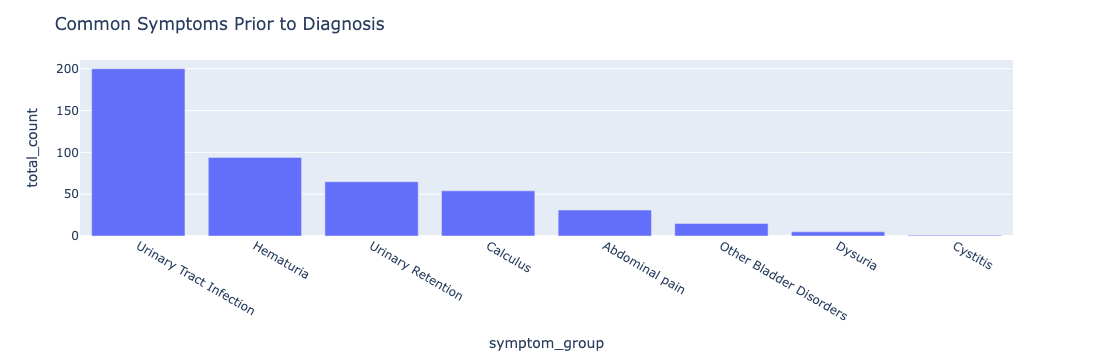

In [7]:
# Getting the top Relevant symptoms seen
# Obtained by searching the relevant visits and only those in the top 10 ranking for the visits

top_symptoms = (
    diagnoses
    .filter( col("visit_type")=="SYMPTOM")
    .join(
        broadcast(icd_codes.filter(col("status") == "RELEVANT")), #broadcast join on filtered dataset
        on=["icd_code","icd_version"],
        how="inner"
    )
    .where(col("ranking") <= 10)
    .withColumn("symptom_group",
                when(F.map_contains_key(symptom_map,col("icd_code")), symptom_map[col("icd_code")])
                .otherwise("Not in List"))
    .groupBy("symptom_group") # decided to just go for top 10, will figure out
    .agg(
        count("*").alias("total_count"),
        count_distinct("subject_id").alias("distinct_patients")
)
    .drop("icd_code","icd_version","status")
    .sort("total_count", ascending=False)
)

top_symptoms.show(10, truncate=False)
fig_top_symptoms= top_symptoms.plot.bar(x="symptom_group", y="total_count").update_layout(title_text="Common Symptoms Prior to Diagnosis")

fig_top_symptoms.show()

+----------+-----------------------+----------+--------------+
|subject_id|symptom_group          |admit_day |sequence_order|
+----------+-----------------------+----------+--------------+
|10120826  |Abdominal pain         |2014-02-20|1             |
|10247438  |Urinary Retention      |2012-11-04|1             |
|10247438  |Hematuria              |2015-08-01|2             |
|10255052  |Urinary Tract Infection|2014-05-31|1             |
|10265482  |Hematuria              |2014-06-06|1             |
|10266052  |Urinary Tract Infection|2018-05-07|1             |
|10266052  |Urinary Retention      |2020-03-27|2             |
|10278306  |Urinary Tract Infection|2013-07-01|1             |
|10278306  |Other Bladder Disorders|2016-05-12|2             |
|10345247  |Hematuria              |2018-03-08|1             |
+----------+-----------------------+----------+--------------+
only showing top 10 rows


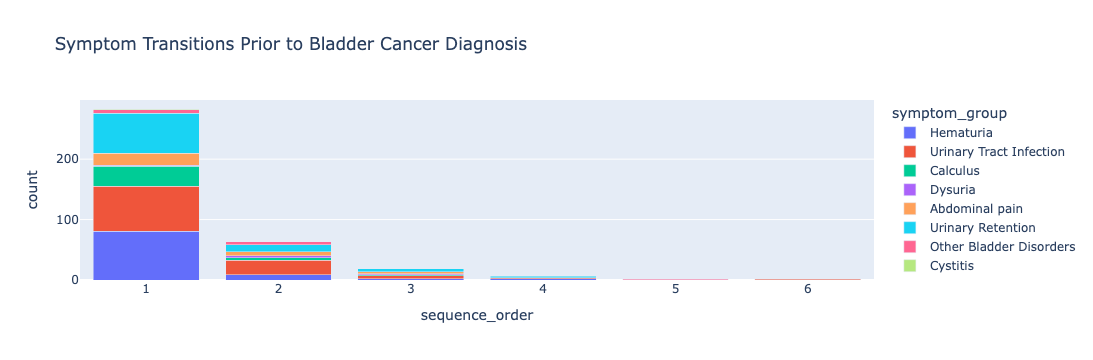

In [8]:
# Now to try to get accumulations based on date

#Need a window that gets the highest rank symptom and assigns it to a group
#Another window that takes those and numbers based on row in window

ranking_group = Window.partitionBy('hadm_id').orderBy(F.desc('ranking'))
ranking_visits = Window.partitionBy('subject_id').orderBy('admit_day')

symptom_pattern_sequences = (
    diagnoses
    .select("subject_id","hadm_id","icd_code","ranking")
    .filter((col("visit_type") == "SYMPTOM" ) & ( F.map_contains_key(symptom_map,col("icd_code"))))
    .withColumn("symptom_group",
                when(F.map_contains_key(symptom_map,col("icd_code")), symptom_map[col("icd_code")])
                .otherwise("Not in List")) #should not hit this
    .withColumn("row_number", F.row_number().over(ranking_group))
    .filter(col("row_number") == 1)
    .join(visits.select("hadm_id","admit_day"), on=["hadm_id"], how="inner")
    .withColumn("repeat", when(F.lag("symptom_group").over(ranking_visits) == col("symptom_group"), "True" ).otherwise("False"))
    .filter( col("repeat")!= "True")
    .withColumn("sequence_order", F.row_number().over(ranking_visits))
    .drop(*["repeat","ranking","hadm_id","icd_code","row_number"]) # The * is needed. Has to do somehow with making it positional?
    .orderBy("subject_id")
)

symptom_pattern_sequences.show(10,truncate=False)

symptom_transitions = symptom_pattern_sequences.groupBy("sequence_order","symptom_group").count().toPandas()
fig_symptom_transitions = px.bar(symptom_transitions, x="sequence_order", y="count", color="symptom_group", title="Symptom Transitions Prior to Bladder Cancer Diagnosis", barmode="stack")

fig_symptom_transitions.show()
# how to pivot it for a stacked bar chart



In [9]:
# Pasted the code block from Data_and_Age transformations (featured in the previous sprint)
# Primarily pasting this here after encountering errors with defining time_difference to properly identify the number of days between a patient's last symptom and their diagnosis (days_before_dx)

# Parsing pre_bc_symptom_timeline because the code block will get fussy without it 
pre_bc_symptom_timeline = spark.read.csv(
    "../../out/evidence/pre_bc_symptom_timeline.csv",
    header=True,
    inferSchema=True
)

symptoms = pre_bc_symptom_timeline.filter(F.col("row_type") == "SYMPTOM")
bc = pre_bc_symptom_timeline.filter(F.col("row_type") == "BC_FIRST_DX")

symptom_counts = (
    symptoms
    .groupBy("subject_id")
    .count()
    .withColumnRenamed("count", "num_of_symptoms")
)

from pyspark.sql.window import Window
the_window = Window.partitionBy("subject_id").orderBy(F.col("admittime").desc())

last_symptoms = (
    symptoms
    .withColumn("rank", F.row_number().over(the_window))
    .filter(F.col("rank") == 1)
    .select("subject_id", F.col("admittime").alias("last_symptom_time"))
)

first_bc = (
    bc
    .select("subject_id", F.col("admittime").alias("bc_time"))
)

time_difference = (
    last_symptoms
    .join(first_bc, on="subject_id", how="inner")
    .join(symptom_counts, on="subject_id", how="inner")
    .withColumn(
        "days_before_dx",
        F.datediff("bc_time", "last_symptom_time")
    )
)

+----------+------+-----------------+------------------+
|age_bucket|gender|distinct_patients|avg_days_before_dx|
+----------+------+-----------------+------------------+
|30-40     |F     |8                |21.0              |
|30-40     |M     |2                |121.0             |
|41-55     |F     |32               |467.6             |
|41-55     |M     |48               |182.5             |
|56-70     |F     |118              |480.5652173913044 |
|56-70     |M     |255              |533.4             |
|71-85     |F     |186              |457.675           |
|71-85     |M     |425              |543.5567010309278 |
|85+       |F     |68               |564.3529411764706 |
|85+       |M     |164              |660.3488372093024 |
+----------+------+-----------------+------------------+



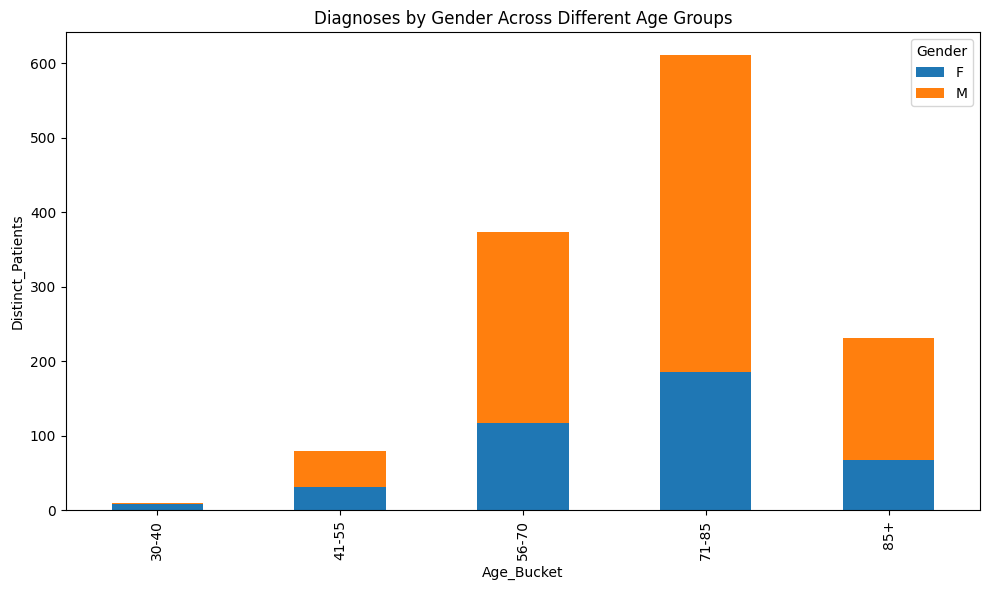

In [10]:
# || Ara's Deliverable || 

# >> Dataframe + Stacked Bar chart to conduct further analysis on whether diagnoses differ by gender across age groups <<

# || DATAFRAME: demographics_age_gender ||

# Note: The following sections of code were retrieved from sprint5.ipynb
# Additional Note (for syntax): There are several forums that like to argue whether F or sf is best practice as a naming convention to import pyspark.sql.functions 

# Parsing through the parquet file containing the first BC diagnoses 
bc_visits = visits.filter(F.col("visit_type") == "BC_FIRST_DX")

# Creating buckets for corresponding ages 
bc_buckets = bc_visits.withColumn(
    "age_bucket",
    F.when(F.col("age") < 30, "<30")
     .when((F.col("age") >= 30) & (F.col("age") <= 40), "30-40")
     .when((F.col("age") >= 41) & (F.col("age") <= 55), "41-55")
     .when((F.col("age") >= 56) & (F.col("age") <= 70), "56-70")
     .when((F.col("age") >= 71) & (F.col("age") <= 85), "71-85")
     .otherwise("85+")
)

# Joining the diagnosis timing (time_difference) by subject_id -> referencing code from sprint5.ipynb - date and age transformation block
bc_buckets = bc_buckets.join(
    time_difference.select("subject_id", "days_before_dx"),
    on="subject_id",
    how="left"
)

# Building the demographics_and_age dataframe 
demographics_age_gender = (
    bc_buckets
    .groupBy("age_bucket", "gender")
    .agg(
        F.countDistinct("subject_id").alias("distinct_patients"),
        F.avg("days_before_dx").alias("avg_days_before_dx")
    )
)

# Sorting the ages into nice buckets (numbered 1-6, with no.7 bucket being a catch-all) 
demographics_age_gender = (
    demographics_age_gender
    .withColumn(
        "age_bucket_order",
        F.when(F.col("age_bucket") == "<30", 1) 
        .when(F.col("age_bucket") == "30-40", 2)
        .when(F.col("age_bucket") == "41-55", 3)
        .when(F.col("age_bucket") == "56-70", 4)
        .when(F.col("age_bucket") == "71-85", 5)
        .when(F.col("age_bucket") == "85+", 6)
        .otherwise(7) 
    )

    .orderBy("age_bucket_order", "gender")
    .drop("age_bucket_order") 
)

demographics_age_gender.show(truncate=False)


# || STACKED BAR CHART: fig_demographics_age_gender || 

# Note: Implementing the use of the pandas library to show the bar chart seamlessly 
dag_df = demographics_age_gender.toPandas() # dag -> demographics_age_gender

age_order = ["<30", "30-40", "41-55", "56-70", "71-85", "85+"]
dag_df["age_bucket"] = pd.Categorical(dag_df["age_bucket"], categories = age_order, ordered = True) 
dag_df = dag_df.sort_values(["age_bucket", "gender"]) 

stacked_bar_chart_df = (dag_df.pivot(index = "age_bucket", columns = "gender", values = "distinct_patients")
                       .fillna(0) 
                      )
fig_demographics_age_gender = stacked_bar_chart_df.plot(
    kind="bar",
    stacked=True,
    figsize= (10, 6) 
)

plt.xlabel("Age_Bucket") 
plt.ylabel("Distinct_Patients")
plt.title("Diagnoses by Gender Across Different Age Groups") 
plt.legend(title="Gender") 
plt.tight_layout() 
plt.show() 

## Clean up
Stop spark session when done

In [11]:
# Uncomment when you are completely done:

spark.stop()